In [69]:
import torch
from spd.models.component_model import ComponentModel
import jpyplot as plt
import numpy as np

In [ ]:
# Load the trained model
model = ComponentModel.from_pretrained("/Users/jack/spd_out/spd/s-f22710e3/model_10000.pth")

# Access the learned rank-1 components for each decomposed layer
for name, components in model.all_components.items():
    print(f"\n{name}:")
    print(f"  V shape: {components.V.shape}")  # (d_in, C)
    print(f"  U shape: {components.U.shape}")  # (C, d_out)

    # Each subcomponent c is V[:, c] ⊗ U[c, :]
    # Full reconstructed weight = V @ U
    print(f"  Reconstructed weight shape: {components.weight.shape}")

Migrating old LR config format to ScheduleConfig


AttributeError: 'ComponentModel' object has no attribute 'all_components'

In [27]:
model._components.linear1.V[:, 0]

tensor([ 0.0190,  0.0190,  0.2308, -0.0113,  0.1282],
       grad_fn=<SelectBackward0>)

In [22]:
model._ci_fns.linear1.layers[0].W.pow(2).sum(0)

tensor([[0.0302, 0.0151, 0.0092, 0.0792, 0.2784, 0.3412, 0.0787, 0.3791, 0.1231,
         0.3859, 0.2832, 0.5050, 0.0104, 0.0133, 0.4784, 0.4927]],
       grad_fn=<SumBackward1>)

In [ ]:
model.target_model(torch.Tensor([[0.3, 0, 0, 0.7, 0.0]]))

tensor([[0.0000, 0.1590, 0.0000, 0.3370, 0.0000]])

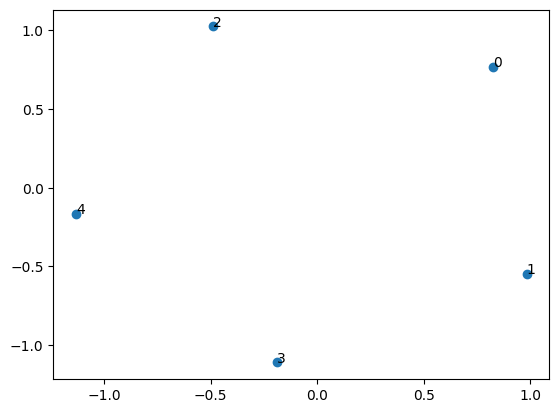

In [70]:
plt.scatter(*model.target_model.linear1.weight, point_labels=np.arange(5))

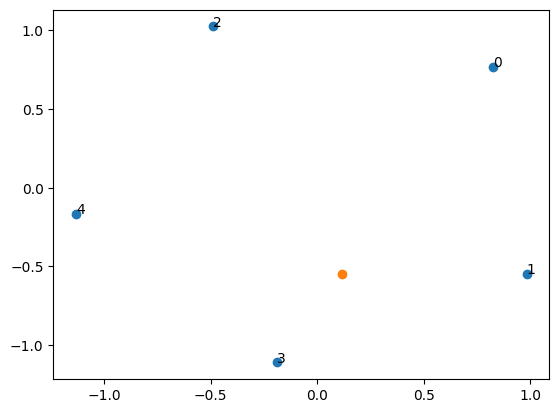

In [82]:
plt.scatter(*model.target_model.linear1.weight, point_labels=np.arange(5))

v = torch.Tensor([[0.3, 0.0, 0.0, 0.7, 0.0]])
v2 = model.target_model.linear1.weight @ v.T
plt.scatter(*v2)

In [88]:
v, model.target_model(v)

(tensor([[0.3000, 0.0000, 0.0000, 0.7000, 0.0000]]),
 tensor([[0.0000, 0.1590, 0.0000, 0.3370, 0.0000]]))

In [118]:
model.target_model.linear1.weight

Parameter containing:
tensor([[ 0.8253,  0.9843, -0.4904, -0.1874, -1.1319],
        [ 0.7684, -0.5487,  1.0253, -1.1113, -0.1662]])

In [ ]:
sum(
    [
        model._components.linear1.U[i].unsqueeze(-1)
        @ model._components.linear1.V[:, i].unsqueeze(0)
        for i in range(20)
    ]
)

tensor([[ 0.2582,  0.3277, -0.0671,  0.0564, -0.4030],
        [ 0.6519, -0.6923,  0.7579, -1.0654,  0.0927]], grad_fn=<AddBackward0>)

In [ ]:
for i in range(20):
    print(
        i,
        model._components.linear1.U[i].unsqueeze(-1)
        @ model._components.linear1.V[:, i].unsqueeze(0),
    )

0 tensor([[ 0.0002, -0.0008, -0.0018, -0.0009, -0.0010],
        [-0.0009,  0.0041,  0.0096,  0.0048,  0.0054]], grad_fn=<MmBackward0>)
1 tensor([[-3.5903e-05, -1.1593e-04,  3.4839e-05, -5.2173e-05,  3.9287e-05],
        [ 1.8935e-03,  6.1137e-03, -1.8373e-03,  2.7515e-03, -2.0720e-03]],
       grad_fn=<MmBackward0>)
2 tensor([[-0.0003, -0.0008,  0.0004, -0.0008,  0.0005],
        [ 0.0018,  0.0042, -0.0018,  0.0040, -0.0024]], grad_fn=<MmBackward0>)
3 tensor([[ 0.0008, -0.0007, -0.0137, -0.0011, -0.0206],
        [-0.0045,  0.0040,  0.0761,  0.0060,  0.1141]], grad_fn=<MmBackward0>)
4 tensor([[ 0.3633, -0.0539,  0.0713, -0.1572, -0.2810],
        [ 0.0615, -0.0091,  0.0121, -0.0266, -0.0476]], grad_fn=<MmBackward0>)
5 tensor([[ 0.0010, -0.0007, -0.0010, -0.0011, -0.0004],
        [-0.0056,  0.0041,  0.0055,  0.0061,  0.0021]], grad_fn=<MmBackward0>)
6 tensor([[ 0.0012, -0.0007, -0.0010, -0.0011,  0.0001],
        [-0.0070,  0.0042,  0.0059,  0.0065, -0.0008]], grad_fn=<MmBackward0>)
7

In [129]:
model._components.linear1.V[:, 0]

tensor([-0.0210,  0.0970,  0.2308,  0.1140,  0.1282],
       grad_fn=<SelectBackward0>)

In [125]:
# model._components.linear1.V.shape

In [119]:
model._components.linear1.U.T @ model._components.linear1.V.T

tensor([[ 0.2582,  0.3277, -0.0671,  0.0564, -0.4030],
        [ 0.6519, -0.6923,  0.7579, -1.0654,  0.0927]], grad_fn=<MmBackward0>)

In [ ]:
model.

ComponentModel(
  (target_model): TMSModel(
    (linear1): Linear(in_features=5, out_features=2, bias=False)
    (linear2): Linear(in_features=2, out_features=5, bias=True)
  )
  (_components): ModuleDict(
    (linear1): LinearComponents()
    (linear2): LinearComponents()
  )
  (_ci_fns): ModuleDict(
    (linear1): MLPCiFn(
      (layers): Sequential(
        (0): ParallelLinear()
        (1): GELU(approximate='none')
        (2): ParallelLinear()
      )
    )
    (linear2): MLPCiFn(
      (layers): Sequential(
        (0): ParallelLinear()
        (1): GELU(approximate='none')
        (2): ParallelLinear()
      )
    )
  )
)

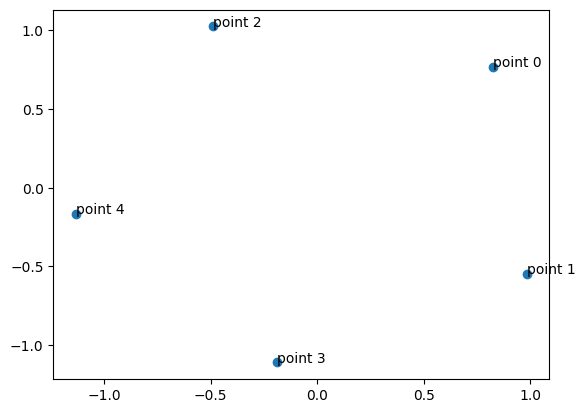

In [ ]:
plt.scatter(*model.target_model.linear1.weight, label="a")
for i, (xi, yi) in enumerate(zip(*model.target_model.linear1.weight)):
    plt.annotate(f"point {i}", (xi, yi))